In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# Import required libraries

import torch
from datasets import load_dataset
from transformers import AutoTokenizer

d:\Collage\AAST\9-AAST 8\Prof AI 3\Emotion Detection in Tweets\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the emotion dataset

dataset = load_dataset("dair-ai/emotion")

# Display dataset structure
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
# Show sample from dataset

dataset["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [5]:
# Load tokenizer for ALBERT model

tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")

In [6]:
# Function to tokenize text

def tokenize(example):
    """
    Convert text into model input format (input_ids, attention_mask)
    """
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Apply tokenization to dataset
dataset = dataset.map(tokenize, batched=True)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 12083.83 examples/s]


In [7]:
# Rename label column to 'labels' (required by Transformers)

dataset = dataset.rename_column("label", "labels")

# Set dataset format for PyTorch
dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [8]:
# Load pre-trained ALBERT model for classification

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "albert-base-v2",
    num_labels=6   # Number of emotion classes
)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# Import metrics
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Define evaluation function
def compute_metrics(eval_pred):
    """
    Compute accuracy and F1 score for model evaluation
    """
    logits, labels = eval_pred
    
    # Get predicted class
    predictions = np.argmax(logits, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    
    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",              # save results
    eval_strategy="epoch",               #evaluate epoch
    save_strategy="epoch",               # save epoch
    learning_rate=2e-5,                  
    per_device_train_batch_size=8,       
    per_device_eval_batch_size=8,
    num_train_epochs=3,                  
    weight_decay=0.01,                   # regularization
    logging_dir="./logs",                # logs
    load_best_model_at_end=True,         
    fp16=True                           
)

In [12]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics
)

In [13]:
# Start training

trainer.train()

  8%|▊         | 501/6000 [01:11<15:16,  6.00it/s]

{'loss': 1.0463, 'grad_norm': 10.610233306884766, 'learning_rate': 1.8350000000000002e-05, 'epoch': 0.25}


 17%|█▋        | 1001/6000 [02:20<11:37,  7.17it/s]

{'loss': 0.4273, 'grad_norm': 12.008171081542969, 'learning_rate': 1.6683333333333333e-05, 'epoch': 0.5}


 25%|██▌       | 1501/6000 [03:29<10:24,  7.21it/s]

...

                                                   
100%|██████████| 6000/6000 [14:32<00:00,  7.26it/s]

{'eval_loss': 0.16803893446922302, 'eval_accuracy': 0.9395, 'eval_f1': 0.9393032703955652, 'eval_runtime': 12.6799, 'eval_samples_per_second': 157.73, 'eval_steps_per_second': 19.716, 'epoch': 3.0}


100%|██████████| 6000/6000 [14:32<00:00,  6.88it/s]

{'train_runtime': 872.4173, 'train_samples_per_second': 55.02, 'train_steps_per_second': 6.877, 'train_loss': 0.27790507634480793, 'epoch': 3.0}


TrainOutput(global_step=6000, training_loss=0.27790507634480793, metrics={'train_runtime': 872.4173, 'train_samples_per_second': 55.02, 'train_steps_per_second': 6.877, 'total_flos': 286890614784000.0, 'train_loss': 0.27790507634480793, 'epoch': 3.0})

In [14]:
# Evaluate on test dataset

predictions = trainer.predict(dataset["test"])

# Extract predictions
import numpy as np

preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Metrics
from sklearn.metrics import accuracy_score, f1_score

print("Test Accuracy:", accuracy_score(labels, preds))
print("Test F1:", f1_score(labels, preds, average="weighted"))

100%|██████████| 250/250 [00:12<00:00, 20.04it/s]

Test Accuracy: 0.9305
Test F1: 0.9289825400298672


In [15]:
from sklearn.metrics import classification_report

print("===== Classification Report =====")
print(classification_report(labels, preds))

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       581
           1       0.93      0.97      0.95       695
           2       0.88      0.73      0.80       159
           3       0.93      0.93      0.93       275
           4       0.88      0.92      0.90       224
           5       0.83      0.68      0.75        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



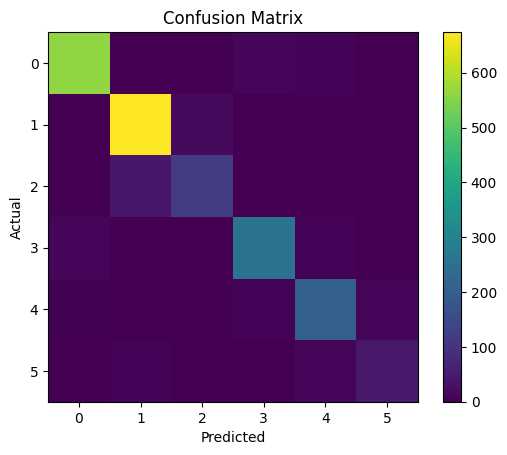

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
def predict(text):
    """
    Predict emotion from input text
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()

    emotions = ["sadness", "joy", "love", "anger", "fear", "surprise"]

    return emotions[pred]

In [ ]:
print(predict("I feel so happy today!"))        # Expected: joy 
print(predict("I am very sad and tired"))       # Expected: sadness 
print(predict("I hate everything"))             # Expected: anger 
print(predict("I am really scared right now"))  # Expected: fear 
print(predict("I love you so much"))            # Expected: love 
print(predict("Wow I didn't expect that!"))     # Expected: surprise 

joy
sadness
anger
fear
love
joy


In [28]:
# Load fresh model (WITHOUT training)

from transformers import AutoModelForSequenceClassification

baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "albert-base-v2",
    num_labels=6
)

baseline_model.to(device)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AlbertForSequenceClassification(
  (albert): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768,

In [29]:
# Create trainer for baseline

baseline_trainer = Trainer(
    model=baseline_model,
    args=training_args,
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics
)

# Evaluate
baseline_results = baseline_trainer.evaluate()

print("Baseline Results:", baseline_results)

100%|██████████| 250/250 [00:13<00:00, 18.23it/s]

Baseline Results: {'eval_loss': 1.8325395584106445, 'eval_accuracy': 0.133, 'eval_f1': 0.03489879986562853, 'eval_runtime': 14.0309, 'eval_samples_per_second': 142.543, 'eval_steps_per_second': 17.818}


In [30]:
from transformers import AutoModelForSequenceClassification

lora_model = AutoModelForSequenceClassification.from_pretrained(
    "albert-base-v2",
    num_labels=6
)

lora_model.to(device)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AlbertForSequenceClassification(
  (albert): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768,

In [ ]:
from peft import LoraConfig, get_peft_model

# Define LoRA config
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],  
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

# Apply LoRA
lora_model = get_peft_model(lora_model, lora_config)

In [33]:
lora_trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics
)

In [34]:
lora_trainer.train()

  8%|▊         | 501/6000 [01:09<13:20,  6.87it/s]

{'loss': 1.6147, 'grad_norm': 5.6269025802612305, 'learning_rate': 1.8336666666666667e-05, 'epoch': 0.25}


 17%|█▋        | 1001/6000 [02:17<11:02,  7.54it/s]

{'loss': 1.5745, 'grad_norm': 7.754128456115723, 'learning_rate': 1.6673333333333335e-05, 'epoch': 0.5}


 25%|██▌       | 1501/6000 [03:25<10:14,  7.32it/s]

...

100%|██████████| 6000/6000 [13:45<00:00,  7.85it/s]

{'loss': 1.3485, 'grad_norm': 9.89242172241211, 'learning_rate': 1.666666666666667e-08, 'epoch': 3.0}



100%|██████████| 6000/6000 [14:00<00:00,  7.14it/s]

{'eval_loss': 1.3010200262069702, 'eval_accuracy': 0.5095, 'eval_f1': 0.40320588235294114, 'eval_runtime': 14.6768, 'eval_samples_per_second': 136.269, 'eval_steps_per_second': 17.034, 'epoch': 3.0}
{'train_runtime': 840.4848, 'train_samples_per_second': 57.11, 'train_steps_per_second': 7.139, 'train_loss': 1.482354522705078, 'epoch': 3.0}


TrainOutput(global_step=6000, training_loss=1.482354522705078, metrics={'train_runtime': 840.4848, 'train_samples_per_second': 57.11, 'train_steps_per_second': 7.139, 'total_flos': 287966674944000.0, 'train_loss': 1.482354522705078, 'epoch': 3.0})

In [35]:
lora_predictions = lora_trainer.predict(dataset["test"])

preds = np.argmax(lora_predictions.predictions, axis=1)
labels = lora_predictions.label_ids

print("LoRA Accuracy:", accuracy_score(labels, preds))
print("LoRA F1:", f1_score(labels, preds, average="weighted"))

100%|██████████| 250/250 [00:14<00:00, 16.88it/s]

LoRA Accuracy: 0.519
LoRA F1: 0.4120841276580477


In [36]:
# Save full fine-tuned model
model.save_pretrained("./model_full")

# Save tokenizer
tokenizer.save_pretrained("./model_full")

('./model_full\\tokenizer_config.json',
 './model_full\\special_tokens_map.json',
 './model_full\\tokenizer.json')

In [ ]:
# Save LoRA model
lora_model.save_pretrained("./model_lora")

# Save tokenizer 
tokenizer.save_pretrained("./model_lora")

d:\Collage\AAST\9-AAST 8\Prof AI 3\Emotion Detection in Tweets\venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


('./model_lora\\tokenizer_config.json',
 './model_lora\\special_tokens_map.json',
 './model_lora\\tokenizer.json')